# Data Wrangling

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import lightning as L
import os
import warnings
warnings.filterwarnings("ignore")
import gc
from PIL import Image
import glob
import json

# set random seed for reproducibility
import random
import numpy as np

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    L.seed_everything(seed)

set_seed(42)

Seed set to 42


In [2]:
# Read train annotations
with open('/Users/muhammadnajmirahmani/ProjectCV/annotations/train.json') as f:
    train = json.load(f)

# Read test annotations
with open('/Users/muhammadnajmirahmani/ProjectCV/annotations/test.json') as f:
    test = json.load(f)

# Read val annotations
with open('/Users/muhammadnajmirahmani/ProjectCV/annotations/val.json') as f:
    val = json.load(f)

# Convert to DataFrame
train_images = pd.DataFrame(train['images'])
test_images = pd.DataFrame(test['images'])
val_images = pd.DataFrame(val['images'])

train_captions = pd.DataFrame(train['annotations'])
val_captions = pd.DataFrame(val['annotations'])


In [3]:
train_images

,file_name,vizwiz_url,id,text_detected
0,VizWiz_train_00000000.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,0,True
1,VizWiz_train_00000001.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,1,True
2,VizWiz_train_00000002.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,2,True
3,VizWiz_train_00000003.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,3,True
4,VizWiz_train_00000004.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,4,True
...,...,...,...,...
23426,VizWiz_train_00023426.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23426,True
23427,VizWiz_train_00023427.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23427,False
23428,VizWiz_train_00023428.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23428,True
23429,VizWiz_train_00023429.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23429,True


In [4]:
train_captions

,caption,image_id,is_precanned,is_rejected,id,text_detected
0,ITS IS A BASIL LEAVES CONTAINER ITS CONTAINS T...,0,False,False,0,True
1,A green and white plastic condiment bottle con...,0,False,False,1,True
2,Quality issues are too severe to recognize vis...,0,True,True,2,True
3,A bottle of spices in a plastic container layi...,0,False,False,3,True
4,some basil leaves in a container on a counter,0,False,False,4,True
...,...,...,...,...,...,...
117150,The back of a plastic card such as a credit ca...,23430,False,False,117150,True
117151,A card is seen with a scratch strip to reveal ...,23430,False,False,117151,True
117152,The back of a gift card without the silver str...,23430,False,False,117152,True
117153,The back of a plastic money or credit card wit...,23430,False,False,117153,True


In [5]:
# Join images and captions for train and val by id
train_df = pd.merge(train_images, train_captions, left_on='id', right_on='image_id')
val_df = pd.merge(val_images, val_captions, left_on='id', right_on='image_id')

In [6]:
train_df.head()

,file_name,vizwiz_url,id_x,text_detected_x,caption,image_id,is_precanned,is_rejected,id_y,text_detected_y
0,VizWiz_train_00000000.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,0,True,ITS IS A BASIL LEAVES CONTAINER ITS CONTAINS T...,0,False,False,0,True
1,VizWiz_train_00000000.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,0,True,A green and white plastic condiment bottle con...,0,False,False,1,True
2,VizWiz_train_00000000.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,0,True,Quality issues are too severe to recognize vis...,0,True,True,2,True
3,VizWiz_train_00000000.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,0,True,A bottle of spices in a plastic container layi...,0,False,False,3,True
4,VizWiz_train_00000000.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,0,True,some basil leaves in a container on a counter,0,False,False,4,True


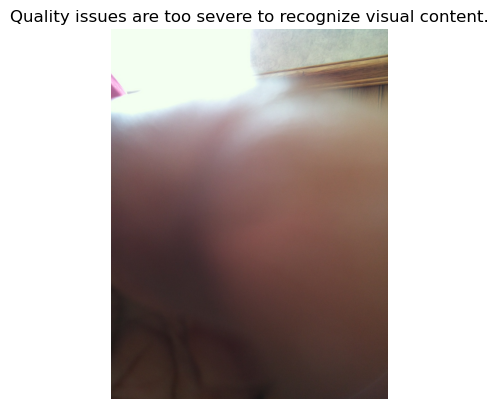

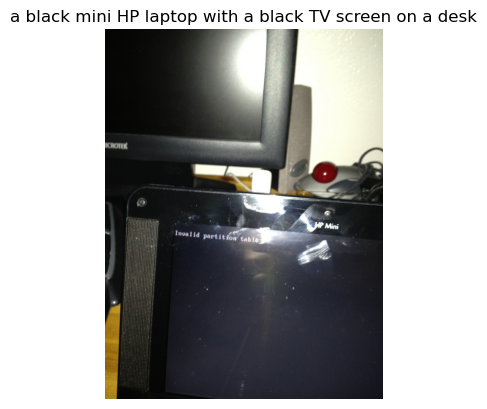

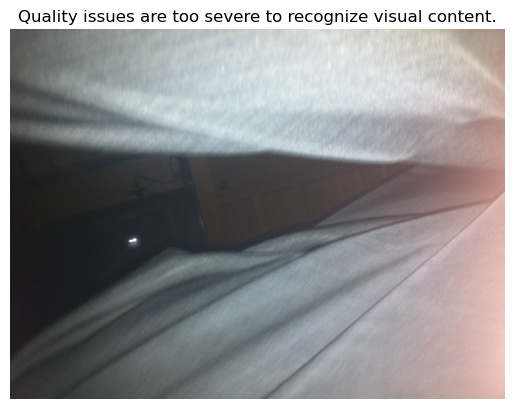

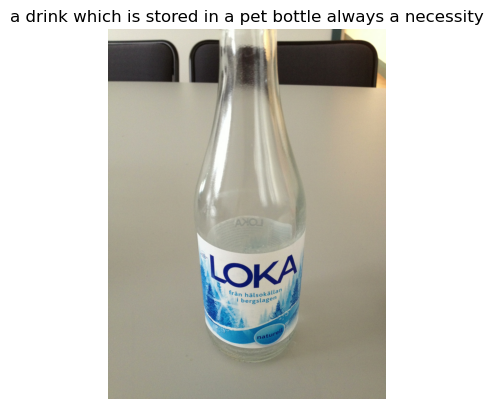

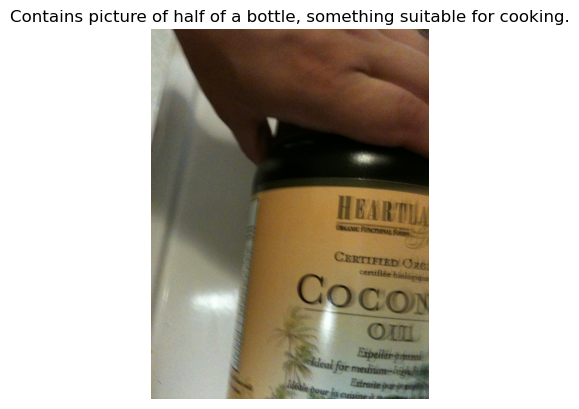

In [7]:
# Ambil beberapa contoh gambar dan caption
sample_images = train_df.sample(5)
# Tampilkan gambar dan caption
for index, row in sample_images.iterrows():
    image_path = os.path.join('/Users/muhammadnajmirahmani/ProjectCV/train', row['file_name'])
    caption = row['caption']
    
    # Tampilkan gambar
    img = plt.imread(image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title(caption)
    plt.show()


In [8]:
# Get size of the images from 5 random samples
sample_images = train_df.sample(5)
for index, row in sample_images.iterrows():
    image_path = os.path.join('/Users/muhammadnajmirahmani/ProjectCV/train', row['file_name'])
    img = plt.imread(image_path)
    print(f"Image: {row['file_name']}, Size: {img.shape}")

Image: VizWiz_train_00006502.jpg, Size: (1632, 1224, 3)
Image: VizWiz_train_00022874.jpg, Size: (1632, 1224, 3)
Image: VizWiz_train_00009567.jpg, Size: (1296, 968, 3)
Image: VizWiz_train_00019882.jpg, Size: (1632, 1224, 3)
Image: VizWiz_train_00023056.jpg, Size: (1296, 968, 3)


In [9]:
# Ambil image yang captionnya diterima
train_df = train_df[train_df['is_rejected'] == False]
val_df = val_df[val_df['is_rejected'] == False]
train_df.head()

,file_name,vizwiz_url,id_x,text_detected_x,caption,image_id,is_precanned,is_rejected,id_y,text_detected_y
0,VizWiz_train_00000000.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,0,True,ITS IS A BASIL LEAVES CONTAINER ITS CONTAINS T...,0,False,False,0,True
1,VizWiz_train_00000000.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,0,True,A green and white plastic condiment bottle con...,0,False,False,1,True
3,VizWiz_train_00000000.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,0,True,A bottle of spices in a plastic container layi...,0,False,False,3,True
4,VizWiz_train_00000000.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,0,True,some basil leaves in a container on a counter,0,False,False,4,True
5,VizWiz_train_00000001.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,1,True,A can of Coca Cola on a counter is shown for w...,1,False,False,5,True


In [10]:
train_img_root = '/Users/muhammadnajmirahmani/ProjectCV/train'
val_img_root = '/Users/muhammadnajmirahmani/ProjectCV/val'
test_img_root = '/Users/muhammadnajmirahmani/ProjectCV/test'

# Text Prepocessing

Preprocessing untuk image captioning

In [11]:
# Buat preprocessing pipeline untuk text pada image caption
import re
import torch
from tokenizers import BertWordPieceTokenizer

def preprocess_caption(caption):
    # Convert to lowercase
    caption = caption.lower()
    # Remove punctuation
    caption = re.sub(r'[^\w\s]', '', caption)
    # Remove extra whitespace
    caption = re.sub(r'\s+', ' ', caption).strip()
    # Remove repeated characters (e.g., "loooove" -> "love")
    caption = re.sub(r'(.)\1{2,}', r'\1', caption)
    # Remove repeated words (e.g., "very very good" -> "very good")
    caption = re.sub(r'\b(\w+)( \1\b)+', r'\1', caption)
    return caption

train_df['processed_caption'] = train_df['caption'].apply(preprocess_caption)
val_df['processed_caption'] = val_df['caption'].apply(preprocess_caption)

# Tambahkan token khusus untuk memulai dan mengakhiri caption
train_df['processed_caption'] = '[START] ' + train_df['processed_caption'] + ' [END]'
val_df['processed_caption'] = '[START] ' + val_df['processed_caption'] + ' [END]'

In [12]:
vocab_words = list(set(" ".join(train_df["processed_caption"]).split()))
print(len(vocab_words))

18916


In [13]:
tokenizer = BertWordPieceTokenizer(
    unk_token="[UNK]",
    clean_text=False,
    lowercase=False
)

tokenizer.train_from_iterator(
    train_df["processed_caption"].tolist(),
    vocab_size=len(vocab_words) + 4,  # +4 for special tokens
    special_tokens=["[PAD]","[UNK]","[START]","[END]"]
)

In [14]:
# Cek apakah token masuk ke dalam vocabulary
vocab = tokenizer.get_vocab()
for token in ["[PAD]", "[UNK]", "[START]", "[END]"]:
    print(f"{token}: {vocab.get(token)}")

[PAD]: 0
[UNK]: 1
[START]: 2
[END]: 3


In [15]:
vocab = tokenizer.get_vocab()
# Encoding a sentence
example_caption = train_df["processed_caption"].iloc[:5]
example_tokenized_captions = tokenizer.encode_batch(example_caption)

print('caption:',example_caption[5])

for token in example_tokenized_captions[0].tokens:
    print('token:',token,"\t\tid:",vocab[token])

caption: [START] a can of coca cola on a counter is shown for when one can use a nice cold drink [END]
token: [START] 		id: 2
token: its 		id: 477
token: is 		id: 117
token: a 		id: 23
token: basil 		id: 3349
token: leaves 		id: 1220
token: container 		id: 310
token: its 		id: 477
token: contains 		id: 817
token: the 		id: 116
token: net 		id: 3160
token: weight 		id: 2232
token: too 		id: 160
token: [END] 		id: 3


In [16]:
print("[START] ID:", tokenizer.token_to_id("[START]"))
print("[END] ID:", tokenizer.token_to_id("[END]"))
print("[PAD] ID:", tokenizer.token_to_id("[PAD]"))

[START] ID: 2
[END] ID: 3
[PAD] ID: 0


In [17]:
train_df

,file_name,vizwiz_url,id_x,text_detected_x,caption,image_id,is_precanned,is_rejected,id_y,text_detected_y,processed_caption
0,VizWiz_train_00000000.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,0,True,ITS IS A BASIL LEAVES CONTAINER ITS CONTAINS T...,0,False,False,0,True,[START] its is a basil leaves container its co...
1,VizWiz_train_00000000.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,0,True,A green and white plastic condiment bottle con...,0,False,False,1,True,[START] a green and white plastic condiment bo...
3,VizWiz_train_00000000.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,0,True,A bottle of spices in a plastic container layi...,0,False,False,3,True,[START] a bottle of spices in a plastic contai...
4,VizWiz_train_00000000.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,0,True,some basil leaves in a container on a counter,0,False,False,4,True,[START] some basil leaves in a container on a ...
5,VizWiz_train_00000001.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,1,True,A can of Coca Cola on a counter is shown for w...,1,False,False,5,True,[START] a can of coca cola on a counter is sho...
...,...,...,...,...,...,...,...,...,...,...,...
117150,VizWiz_train_00023430.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23430,True,The back of a plastic card such as a credit ca...,23430,False,False,117150,True,[START] the back of a plastic card such as a c...
117151,VizWiz_train_00023430.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23430,True,A card is seen with a scratch strip to reveal ...,23430,False,False,117151,True,[START] a card is seen with a scratch strip to...
117152,VizWiz_train_00023430.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23430,True,The back of a gift card without the silver str...,23430,False,False,117152,True,[START] the back of a gift card without the si...
117153,VizWiz_train_00023430.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23430,True,The back of a plastic money or credit card wit...,23430,False,False,117153,True,[START] the back of a plastic money or credit ...


# Feature Extraction

Pakai ViT untuk extraksi fitur

In [18]:
from transformers import ViTImageProcessor, ViTModel
import torch
import torch.nn as nn

class HuggingFaceViTEncoder(nn.Module):
    def __init__(self, model_name="google/vit-base-patch16-224-in21k"):
        super(HuggingFaceViTEncoder, self).__init__()
        # 1. Load Processor (untuk resize & normalisasi otomatis)
        self.processor = ViTImageProcessor.from_pretrained(model_name)
        
        # 2. Load Model (Tanpa head klasifikasi)
        self.model = ViTModel.from_pretrained(model_name)
        
        # 3. Freeze parameter (opsional di awal training)
        for param in self.model.parameters():
            param.requires_grad = False

    def forward(self, images):
        """
        images: tensor dari dataloader (batch, 3, 224, 224)
        """
        # Jalankan melalui model ViT
        outputs = self.model(pixel_values=images)
        
        # 'last_hidden_state' berisi fitur dari semua patch
        # Shape: (batch_size, 197, 768)
        # 197 berasal dari 1 CLS token + 196 patches (14x14)
        last_hidden_state = outputs.last_hidden_state
        
        # Kita ambil HANYA patch features (indeks 1 sampai akhir)
        # (batch, 196, 768)
        patch_features = last_hidden_state[:, 1:, :]
        
        return patch_features
    
# Extract features untuk 5 gambar sampel
sample_images = train_df.sample(5)
encoder = HuggingFaceViTEncoder()
for index, row in sample_images.iterrows():
    image_path = os.path.join(train_img_root, row['file_name'])
    img = plt.imread(image_path)
    # Preprocess gambar menggunakan processor
    inputs = encoder.processor(images=img, return_tensors="pt")
    pixel_values = inputs['pixel_values']  # Shape: (1, 3, 224, 224)
    # Extract fitur patch
    with torch.no_grad():
        patch_features = encoder(pixel_values)  # Shape: (1, 196, 768) 768 dimensi embedding
    print(f"Image: {row['file_name']}, Patch Features Shape: {patch_features.shape}")
    

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Image: VizWiz_train_00001482.jpg, Patch Features Shape: torch.Size([1, 196, 768])
Image: VizWiz_train_00017884.jpg, Patch Features Shape: torch.Size([1, 196, 768])
Image: VizWiz_train_00020676.jpg, Patch Features Shape: torch.Size([1, 196, 768])
Image: VizWiz_train_00000124.jpg, Patch Features Shape: torch.Size([1, 196, 768])
Image: VizWiz_train_00002274.jpg, Patch Features Shape: torch.Size([1, 196, 768])


In [19]:
# Image.open(image_path).convert("RGB")

In [20]:
train_images

,file_name,vizwiz_url,id,text_detected
0,VizWiz_train_00000000.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,0,True
1,VizWiz_train_00000001.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,1,True
2,VizWiz_train_00000002.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,2,True
3,VizWiz_train_00000003.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,3,True
4,VizWiz_train_00000004.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,4,True
...,...,...,...,...
23426,VizWiz_train_00023426.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23426,True
23427,VizWiz_train_00023427.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23427,False
23428,VizWiz_train_00023428.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23428,True
23429,VizWiz_train_00023429.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23429,True


In [21]:
train_captions

,caption,image_id,is_precanned,is_rejected,id,text_detected
0,ITS IS A BASIL LEAVES CONTAINER ITS CONTAINS T...,0,False,False,0,True
1,A green and white plastic condiment bottle con...,0,False,False,1,True
2,Quality issues are too severe to recognize vis...,0,True,True,2,True
3,A bottle of spices in a plastic container layi...,0,False,False,3,True
4,some basil leaves in a container on a counter,0,False,False,4,True
...,...,...,...,...,...,...
117150,The back of a plastic card such as a credit ca...,23430,False,False,117150,True
117151,A card is seen with a scratch strip to reveal ...,23430,False,False,117151,True
117152,The back of a gift card without the silver str...,23430,False,False,117152,True
117153,The back of a plastic money or credit card wit...,23430,False,False,117153,True


In [22]:
# import pickle

# images = []
# sample_images = train_df.sample(min(512, len(train_df)), random_state=42).reset_index(drop=True)

# for index, row in train_images.iterrows():
#     image_path = os.path.join(train_img_root, row['file_name'])
#     img = Image.open(image_path).convert("RGB")
#     img = encoder.processor(images=img, return_tensors="pt")['pixel_values'].squeeze(0)  # Shape: (3, 224, 224)
#     images.append(img)

In [23]:
# with open('sample_images.pkl', 'wb') as f:
#     pickle.dump(images, f)

In [24]:
pixel_values

tensor([[[[-0.9216, -0.9216, -0.9216,  ..., -0.9451, -0.9451, -0.9451],
          [-0.9216, -0.9216, -0.9137,  ..., -0.9451, -0.9451, -0.9451],
          [-0.9216, -0.9216, -0.9137,  ..., -0.9451, -0.9451, -0.9451],
          ...,
          [-0.7804, -0.7882, -0.7882,  ..., -0.9843, -0.9843, -0.9843],
          [-0.7882, -0.7882, -0.7882,  ..., -0.9686, -0.9843, -0.9843],
          [-0.7882, -0.7882, -0.7882,  ..., -0.9216, -0.9451, -0.9686]],

         [[-0.9216, -0.9216, -0.9216,  ..., -0.9451, -0.9451, -0.9451],
          [-0.9216, -0.9216, -0.9137,  ..., -0.9451, -0.9451, -0.9451],
          [-0.9216, -0.9216, -0.9137,  ..., -0.9451, -0.9451, -0.9451],
          ...,
          [-0.8980, -0.9059, -0.9059,  ..., -0.9843, -0.9843, -0.9843],
          [-0.9059, -0.9059, -0.9137,  ..., -0.9608, -0.9843, -0.9843],
          [-0.9059, -0.9059, -0.9137,  ..., -0.9216, -0.9451, -0.9686]],

         [[-0.9373, -0.9373, -0.9373,  ..., -0.9608, -0.9608, -0.9529],
          [-0.9373, -0.9373, -

In [25]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader

# Pastikan processor tersedia dari model ViT yang sama
vit_model_name = "google/vit-base-patch16-224-in21k"
vit_processor = ViTImageProcessor.from_pretrained(vit_model_name)

# Penting: reset index setelah filtering agar indexing Dataset aman
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

class CaptionDataset(Dataset):
    def __init__(self, df, img_root, processor, vocab):
        self.df = df
        self.img_root = img_root
        self.processor = processor
        self.vocab = vocab

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = os.path.join(self.img_root, row["file_name"])

        image = Image.open(image_path).convert("RGB")
        pixel_values = self.processor(images=image, return_tensors="pt")["pixel_values"].squeeze(0)

        # Turn into tensor of token ids
        caption_ids = torch.tensor(tokenizer.encode(row["processed_caption"]).ids, dtype=torch.long)
        return pixel_values, caption_ids

from torch.nn.utils.rnn import pad_sequence

def caption_collate_fn(batch):
    pixel_values, captions = zip(*batch)
    pixel_values = torch.stack(pixel_values, dim=0)
    captions = pad_sequence(captions, batch_first=True, padding_value=tokenizer.token_to_id("[PAD]"))
    return pixel_values, captions

# Supaya cepat untuk belajar awal, pakai subset kecil dulu
train_subset = train_df.sample(min(512, len(train_df)), random_state=42).reset_index(drop=True)
val_subset = val_df.sample(min(128, len(val_df)), random_state=42).reset_index(drop=True)

train_dataset = CaptionDataset(train_df, train_img_root, vit_processor, vocab)
val_dataset = CaptionDataset(val_df, val_img_root, vit_processor, vocab)

train_loader = DataLoader(train_dataset, 
                          batch_size=32, 
                          shuffle=True, 
                          num_workers=0, 
                          collate_fn=caption_collate_fn
                          )
val_loader = DataLoader(val_dataset, 
                        batch_size=32, 
                        shuffle=False, 
                        num_workers=0, 
                        collate_fn=caption_collate_fn
                        )

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")

Train samples: 113987, Val samples: 37786


In [26]:
# Get caption ids untuk batch pertama
for batch in train_loader:
    pixel_values, caption_ids = batch
    print("Pixel Values Shape:", pixel_values.shape)  # (batch_size, 3, 224, 224)
    print("Caption IDs Shape:", caption_ids.shape)    # (batch_size, max_caption_length)
    print("Caption IDs:", caption_ids[0])  # Lihat token ids untuk caption pertama di batch
    break

Pixel Values Shape: torch.Size([32, 3, 224, 224])
Caption IDs Shape: torch.Size([32, 23])
Caption IDs: tensor([   2,   23,  190,  104,  302,  710,  267,   23,  272,  119,  200, 2451,
         104,   23, 1270,   37, 6520,    3,    0,    0,    0,    0,    0])


In [27]:
# Word embedding dengan Word2Vec atau GloVe bisa dilakukan di sini, tapi untuk model captioning biasanya kita langsung belajar embedding dari awal (randomly initialized) karena kita ingin model belajar representasi yang optimal untuk tugas captioning. Namun, jika kamu ingin mencoba pre-trained embeddings, kamu bisa menggunakan library seperti Gensim untuk memuat Word2Vec atau GloVe dan membuat matriks embedding yang sesuai dengan vocabulary yang sudah dibuat.

In [34]:
import torch.nn.functional as F
import math

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=2048):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(0.1)
        
    def forward(self, x):
        x = self.dropout(F.relu(self.linear1(x)))
        x = self.linear2(x)
        return x

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                             (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)].detach()
        return self.dropout(x)

class LSTMWithCrossAttentionDecoder(nn.Module):
    def __init__(
        self,
        vocab_size,
        pad_idx,
        embed_dim=256,
        hidden_dim=512,
        encoder_dim=768,
        num_layers=1,
        num_heads=8,
        dropout=0.1,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # Query dim = hidden_dim, Key/Value dim = encoder_dim
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            kdim=encoder_dim,
            vdim=encoder_dim,
            dropout=dropout,
            batch_first=True,
        )

        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, vocab_size)

    def forward(self, captions_in, encoder_features):
        # captions_in: (B, T), encoder_features: (B, N, encoder_dim)
        emb = self.embedding(captions_in)              # (B, T, E)
        lstm_out, _ = self.lstm(emb)                   # (B, T, H)

        attn_out, attn_weights = self.cross_attn(
            query=lstm_out,
            key=encoder_features,
            value=encoder_features,
            need_weights=True,
        )                                               # (B, T, H)

        # Residual + norm setelah attention
        attn_out = self.norm(lstm_out + attn_out)

        fused = torch.cat([lstm_out, attn_out], dim=-1)
        logits = self.fc(self.dropout(fused))          # (B, T, vocab_size)
        return logits, attn_weights

class TransformerDecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, encoder_dim=768, dropout=0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, num_heads)
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            kdim=encoder_dim,
            vdim=encoder_dim,
            dropout=dropout,
            batch_first=True,
        )
        self.ffn = FeedForward(d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(0.1)
        
    def forward(self, x, enc_output, src_mask, tgt_mask):
        # Self attention 
        attn_output, _ = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_output))
        
        # Cross attention (k, v dari encoder)
        attn_output, _ = self.cross_attn(x, enc_output, enc_output, src_mask)
        x = self.norm2(x + self.dropout(attn_output))
        
        # Feed forward
        ffn_output = self.ffn(x)
        x = self.norm3(x + self.dropout(ffn_output))
        return x

class ViTImageCaptioner(nn.Module):
    def __init__(self, model_name, vocab_size, pad_idx, d_model, freeze_encoder=True):
        super().__init__()
        self.encoder = ViTModel.from_pretrained(model_name)
        self.positional_encoding = PositionalEncoding(d_model=d_model, dropout=0.1)

        if freeze_encoder:
            for p in self.encoder.parameters():
                p.requires_grad = False

        self.d_model = d_model
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx) # Embedding untuk input caption
        self.decoder = TransformerDecoderLayer(d_model=d_model, num_heads=8)
        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(self, pixel_values, captions_in):
        encoder_out = self.encoder(pixel_values=pixel_values).last_hidden_state
        patch_features = encoder_out[:, 1:, :]  # buang CLS token
        
        # Embed input caption
        embedded_captions = self.embedding(captions_in)  # (B, T, d_model)

        # Positional encoding
        embedded_captions = self.positional_encoding(embedded_captions)

        # Decode dengan cross attention k, v dari patch features
        decoder_output = self.decoder(embedded_captions, patch_features, src_mask=None, tgt_mask=None)  # (B, T, d_model)
        logits = self.fc_out(decoder_output)  # (B, T, vocab_size)
        return logits, None  # Untuk attn_weights set None dulu
        

class ViTLSTMCaptioner(nn.Module):
    def __init__(self, model_name, vocab_size, pad_idx, freeze_encoder=True):
        super().__init__()
        self.encoder = ViTModel.from_pretrained(model_name)

        if freeze_encoder:
            for p in self.encoder.parameters():
                p.requires_grad = False

        self.decoder = LSTMWithCrossAttentionDecoder(
            vocab_size=vocab_size,
            pad_idx=pad_idx,
            embed_dim=256,
            hidden_dim=512,
            encoder_dim=self.encoder.config.hidden_size,
            num_layers=1,
            num_heads=8,
            dropout=0.1,
        )

    def forward(self, pixel_values, captions_in):
        encoder_out = self.encoder(pixel_values=pixel_values).last_hidden_state
        patch_features = encoder_out[:, 1:, :]  # buang CLS token
        logits, attn_weights = self.decoder(captions_in, patch_features)
        return logits, attn_weights

device = "mps" if torch.backends.mps.is_available() else "cpu"
pad_idx = tokenizer.token_to_id("[PAD]")
model = ViTImageCaptioner(
    model_name="google/vit-base-patch16-224-in21k",
    vocab_size=tokenizer.get_vocab_size(),
    pad_idx=pad_idx,
    d_model=512,
    freeze_encoder=True,
).to(device)
print(f"Device: {device}")
print(f"Jumlah parameter trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Device: mps
Jumlah parameter trainable: 23,796,651


In [35]:
from tqdm.notebook import tqdm

# # Full dataset (semua data)
# train_dataset = CaptionDataset(train_df, train_img_root, vit_processor, vocab)
# val_dataset = CaptionDataset(val_df, val_img_root, vit_processor, vocab)

# batch_size = 32

# train_loader = DataLoader(
#     train_dataset,
#     batch_size=batch_size,
#     shuffle=True,
#     num_workers=0,
#     collate_fn=caption_collate_fn,
# )

# val_loader = DataLoader(
#     val_dataset,
#     batch_size=batch_size,
#     shuffle=False,
#     num_workers=0,
#     collate_fn=caption_collate_fn,
# )

criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
)

# Scheduler: turunkan LR jika val loss stagnan
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1,
)

num_epochs = 4
best_val_loss = float("inf")
early_stopping_patience = 3
epochs_no_improve = 0

# Set ke None kalau mau full training
max_train_batches = None
max_val_batches = None

history = {"train_loss": [], "val_loss": [], "lr": []}

for epoch in range(num_epochs):
    # ---- Train ----
    model.train()
    train_loss_sum = 0.0
    train_steps = 0

    train_pbar = tqdm(train_loader, desc=f"Train Epoch {epoch+1}/{num_epochs}", leave=False)
    for batch_idx, (pixel_values, captions) in enumerate(train_pbar):
        if max_train_batches is not None and batch_idx >= max_train_batches:
            break

        pixel_values = pixel_values.to(device)
        captions = captions.to(device)

        captions_in = captions[:, :-1]
        captions_target = captions[:, 1:]

        optimizer.zero_grad()
        logits, _ = model(pixel_values, captions_in)

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            captions_target.reshape(-1),
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss_sum += loss.item()
        train_steps += 1
        train_pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_train_loss = train_loss_sum / max(train_steps, 1)

    # ---- Validation ----
    model.eval()
    val_loss_sum = 0.0
    val_steps = 0

    with torch.no_grad():
        val_pbar = tqdm(val_loader, desc=f"Val Epoch {epoch+1}/{num_epochs}", leave=False)
        for batch_idx, (pixel_values, captions) in enumerate(val_pbar):
            if max_val_batches is not None and batch_idx >= max_val_batches:
                break

            pixel_values = pixel_values.to(device)
            captions = captions.to(device)

            captions_in = captions[:, :-1]
            captions_target = captions[:, 1:]

            logits, _ = model(pixel_values, captions_in)
            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                captions_target.reshape(-1),
            )

            val_loss_sum += loss.item()
            val_steps += 1
            val_pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_val_loss = val_loss_sum / max(val_steps, 1)

    scheduler.step(avg_val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["lr"].append(current_lr)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"LR: {current_lr:.2e}"
    )

    # Simpan model terbaik
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "best_val_loss": best_val_loss,
            },
            "best_vit_lstm_captioner.pth",
        )
        print("Best model saved.")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= early_stopping_patience:
        print("Early stopping triggered.")
        break

print("Training selesai.")

Train Epoch 1/4:   0%|          | 0/3563 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Visualisasi kurva training
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 3))
plt.plot(history["lr"], label="Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.title("Learning Rate Schedule")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Skema training image captioning (ViT + Transformer Decoder Layer)

training_schema = {
    "1) Input": "Batch dari train_loader -> (pixel_values, captions)",
    "2) Teacher Forcing": "captions_in = captions[:, :-1], target = captions[:, 1:]",
    "3) Forward": "pixel_values -> ViT encoder -> patch features -> token embedding + positional encoding -> Transformer decoder layer (self-attn + cross-attn + FFN) -> logits",
    "4) Loss": "CrossEntropyLoss(logits vs target, ignore_index=[PAD])",
    "5) Backprop": "zero_grad -> backward -> gradient clipping -> optimizer.step()",
    "6) Validation": "Hitung val loss tanpa gradient",
    "7) Scheduler": "ReduceLROnPlateau berdasarkan val loss",
    "8) Checkpoint": "Simpan model terbaik jika val loss membaik",
    "9) Early Stopping": "Stop jika tidak ada perbaikan selama beberapa epoch",
}

print("=== SKEMA TRAINING IMAGE CAPTIONING (ViT + Transformer Decoder) ===")
for k, v in training_schema.items():
    print(f"{k}\n   {v}")

# Verifikasi shape dari 1 batch
pixel_values, captions = next(iter(train_loader))
pixel_values = pixel_values.to(device)
captions = captions.to(device)

captions_in = captions[:, :-1]
captions_target = captions[:, 1:]

with torch.no_grad():
    logits, _ = model(pixel_values, captions_in)

print("\n=== VERIFIKASI SHAPE ===")
print("pixel_values      :", tuple(pixel_values.shape))      # (B, 3, 224, 224)
print("captions          :", tuple(captions.shape))          # (B, T)
print("captions_in       :", tuple(captions_in.shape))       # (B, T-1)
print("captions_target   :", tuple(captions_target.shape))   # (B, T-1)
print("logits            :", tuple(logits.shape))            # (B, T-1, vocab_size)

print("\n=== PENJELASAN SINGKAT ===")
print(
    "Model dilatih dengan teacher forcing: prediksi token ke-t menggunakan urutan token input.\n"
    "ViT mengekstrak fitur patch gambar, lalu Transformer decoder memproses caption embedding\n"
    "dan melakukan cross-attention ke fitur gambar untuk menghasilkan logits kata.\n"
    "Loss mengabaikan [PAD], parameter di-update dengan AdamW, lalu divalidasi tiap epoch.\n"
    "Scheduler LR, checkpoint terbaik, dan early stopping dipakai agar training stabil."
)